# 🤖 Customer Churn — Modelling
**Kaggle Playground Series 2026**

Two-model blend: **LightGBM** + **Logistic Regression**.
Both trained with 5-fold stratified CV. Final submission = weighted average of OOF-optimised blend.

### Structure
1. Setup & Load
2. LightGBM — 5-fold CV
3. Logistic Regression — 5-fold CV
4. Blend optimisation
5. OOF Analysis
6. Feature Importance (LightGBM)
7. Submission

---
## 1. Setup & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED    = 42
N_FOLDS = 5

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/processed/"
OUT_DIR  = "/Users/clairedebadts/kaggle/customer-churn/"

X_train  = pd.read_csv(DATA_DIR + "X_train.csv")
y_train  = pd.read_csv(DATA_DIR + "y_train.csv").squeeze()
X_test   = pd.read_csv(DATA_DIR + "X_test.csv")
test_ids = pd.read_csv(DATA_DIR + "test_ids.csv")

FEATURE_COLS = X_train.columns.tolist()

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}  |  churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}")


X_train : (594194, 41)
y_train : (594194,)  |  churn rate: 22.52%
X_test  : (254655, 41)


---
## 2. LightGBM — 5-Fold CV

Shallow trees, early stopping, `is_unbalance` for class imbalance.

In [3]:
params_lgb = {
    'objective'         : 'binary',
    'metric'            : 'auc',
    'learning_rate'     : 0.05,
    'num_leaves'        : 31,
    'max_depth'         : 6,
    'min_child_samples' : 50,
    'feature_fraction'  : 0.8,
    'bagging_fraction'  : 0.8,
    'bagging_freq'      : 5,
    'lambda_l1'         : 0.1,
    'lambda_l2'         : 1.0,
    'is_unbalance'      : True,
    'verbose'           : -1,
    'random_state'      : SEED,
}

skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_lgb      = np.zeros(len(X_train))
tst_lgb      = np.zeros(len(X_test))
scores_lgb   = []
gain_imp     = np.zeros(len(FEATURE_COLS))
split_imp    = np.zeros(len(FEATURE_COLS))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params_lgb,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    oof_lgb[val_idx] = model.predict(X_val)
    tst_lgb         += model.predict(X_test) / N_FOLDS
    gain_imp        += model.feature_importance(importance_type='gain')  / N_FOLDS
    split_imp       += model.feature_importance(importance_type='split') / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    scores_lgb.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_lgb = roc_auc_score(y_train, oof_lgb)
print(f"\n  OOF AUC  : {auc_lgb:.5f}")
print(f"  Mean     : {np.mean(scores_lgb):.5f} +/- {np.std(scores_lgb):.5f}")


[100]	valid_0's auc: 0.913388
[200]	valid_0's auc: 0.914847
[300]	valid_0's auc: 0.915224
[400]	valid_0's auc: 0.915561
[500]	valid_0's auc: 0.915626
[600]	valid_0's auc: 0.915702
[700]	valid_0's auc: 0.915789
[800]	valid_0's auc: 0.915851
  Fold 1 — AUC: 0.91585 | best iter: 799
[100]	valid_0's auc: 0.914427
[200]	valid_0's auc: 0.915844
[300]	valid_0's auc: 0.916281
[400]	valid_0's auc: 0.916499
[500]	valid_0's auc: 0.916632
[600]	valid_0's auc: 0.916733
[700]	valid_0's auc: 0.916752
[800]	valid_0's auc: 0.916801
[900]	valid_0's auc: 0.916848
[1000]	valid_0's auc: 0.916816
  Fold 2 — AUC: 0.91685 | best iter: 924
[100]	valid_0's auc: 0.914014
[200]	valid_0's auc: 0.915262
[300]	valid_0's auc: 0.915693
[400]	valid_0's auc: 0.91594
[500]	valid_0's auc: 0.916083
[600]	valid_0's auc: 0.916157
[700]	valid_0's auc: 0.916225
[800]	valid_0's auc: 0.916269
[900]	valid_0's auc: 0.916273
  Fold 3 — AUC: 0.91629 | best iter: 873
[100]	valid_0's auc: 0.915038
[200]	valid_0's auc: 0.91648
[300]	va

---
## 3. Logistic Regression — 5-Fold CV

Scaled features, L2 regularisation, `class_weight='balanced'` for imbalance.
Fast to train — adds diversity to the blend through a fundamentally different model family.

In [4]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=0.1,                    # L2 regularisation — tuned for this dataset size
        max_iter=1000,
        class_weight='balanced',  # handles 77/23 imbalance
        solver='lbfgs',
        random_state=SEED,
        n_jobs=-1,
    ))
])

oof_lr    = np.zeros(len(X_train))
tst_lr    = np.zeros(len(X_test))
scores_lr = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    pipe_lr.fit(X_tr, y_tr)

    oof_lr[val_idx] = pipe_lr.predict_proba(X_val)[:, 1]
    tst_lr         += pipe_lr.predict_proba(X_test)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_lr[val_idx])
    scores_lr.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f}")

auc_lr = roc_auc_score(y_train, oof_lr)
print(f"\n  OOF AUC  : {auc_lr:.5f}")
print(f"  Mean     : {np.mean(scores_lr):.5f} +/- {np.std(scores_lr):.5f}")
print(f"\n  LGB : {auc_lgb:.5f}")
print(f"  LR  : {auc_lr:.5f}")


  Fold 1 — AUC: 0.91038
  Fold 2 — AUC: 0.91165
  Fold 3 — AUC: 0.91108
  Fold 4 — AUC: 0.91213
  Fold 5 — AUC: 0.90894

  OOF AUC  : 0.91083
  Mean     : 0.91084 +/- 0.00111

  LGB : 0.91622
  LR  : 0.91083


---
## 4. Blend Optimisation

Find the weight `w` that maximises OOF AUC for:
`blend = w * LGB + (1-w) * LR`

Optimised on OOF predictions — no data leakage.

Blend optimisation results:
  Best weight (LGB) : 0.95
  Best weight (LR)  : 0.05
  Blend OOF AUC     : 0.91624
  vs LGB alone      : 0.91622  (+0.00001)
  vs LR alone       : 0.91083  (+0.00541)


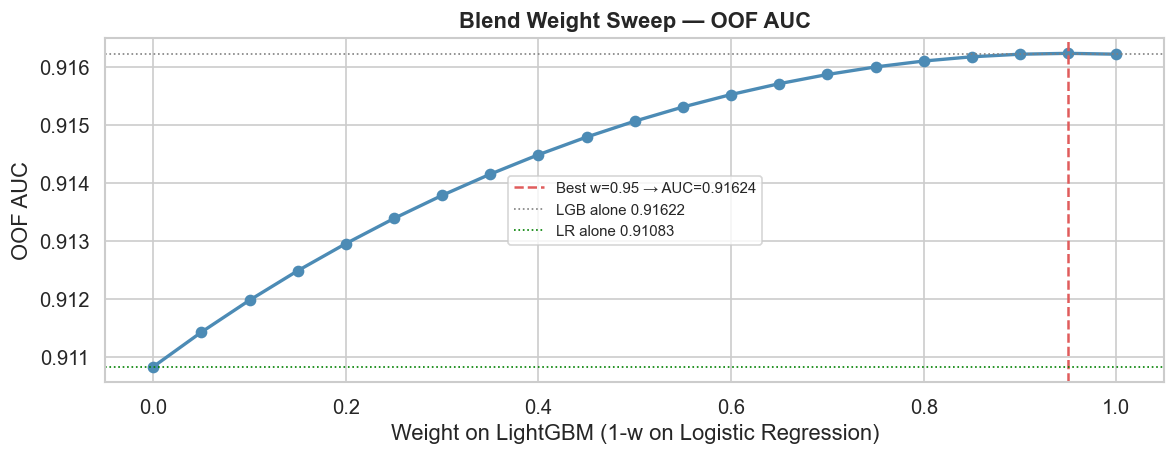

In [5]:
best_w, best_auc = 0.5, 0.0

for w in np.arange(0.0, 1.01, 0.05):
    blend_oof = w * oof_lgb + (1 - w) * oof_lr
    auc       = roc_auc_score(y_train, blend_oof)
    if auc > best_auc:
        best_auc, best_w = auc, w

print(f"Blend optimisation results:")
print(f"  Best weight (LGB) : {best_w:.2f}")
print(f"  Best weight (LR)  : {1-best_w:.2f}")
print(f"  Blend OOF AUC     : {best_auc:.5f}")
print(f"  vs LGB alone      : {auc_lgb:.5f}  ({best_auc - auc_lgb:+.5f})")
print(f"  vs LR alone       : {auc_lr:.5f}  ({best_auc - auc_lr:+.5f})")

# Weight sweep plot
weights   = np.arange(0.0, 1.01, 0.05)
auc_sweep = [roc_auc_score(y_train, w*oof_lgb + (1-w)*oof_lr) for w in weights]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weights, auc_sweep, marker='o', color='#4C8BB5', linewidth=2)
ax.axvline(best_w, color='#E05C5C', linestyle='--', linewidth=1.5,
           label=f'Best w={best_w:.2f} → AUC={best_auc:.5f}')
ax.axhline(auc_lgb, color='grey', linestyle=':', linewidth=1, label=f'LGB alone {auc_lgb:.5f}')
ax.axhline(auc_lr,  color='green', linestyle=':', linewidth=1, label=f'LR alone {auc_lr:.5f}')
ax.set_title('Blend Weight Sweep — OOF AUC', fontweight='bold')
ax.set_xlabel('Weight on LightGBM (1-w on Logistic Regression)')
ax.set_ylabel('OOF AUC')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Final blended predictions
oof_blend = best_w * oof_lgb + (1 - best_w) * oof_lr
tst_blend = best_w * tst_lgb + (1 - best_w) * tst_lr


---
## 5. OOF Analysis

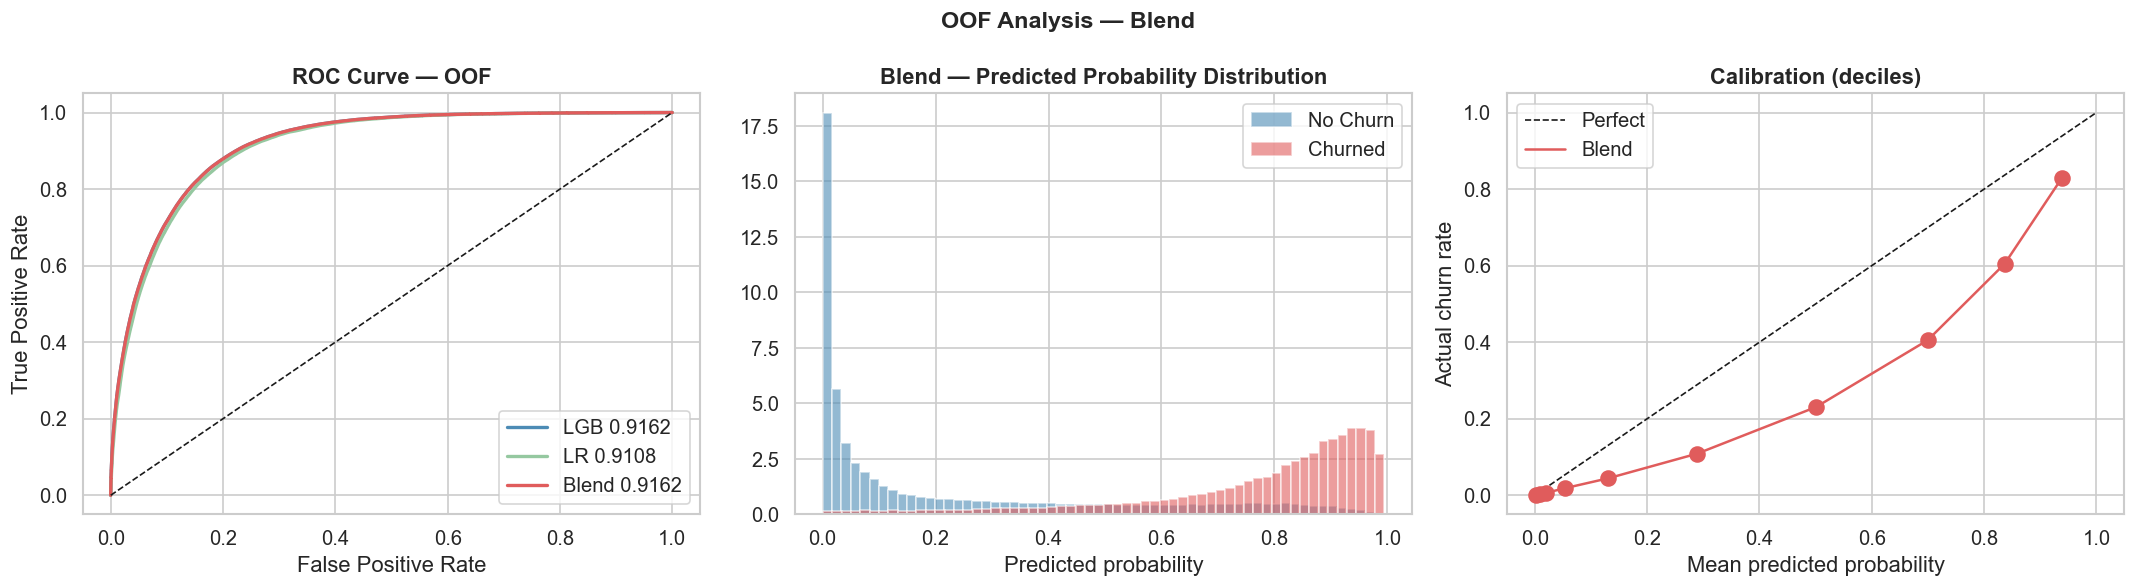

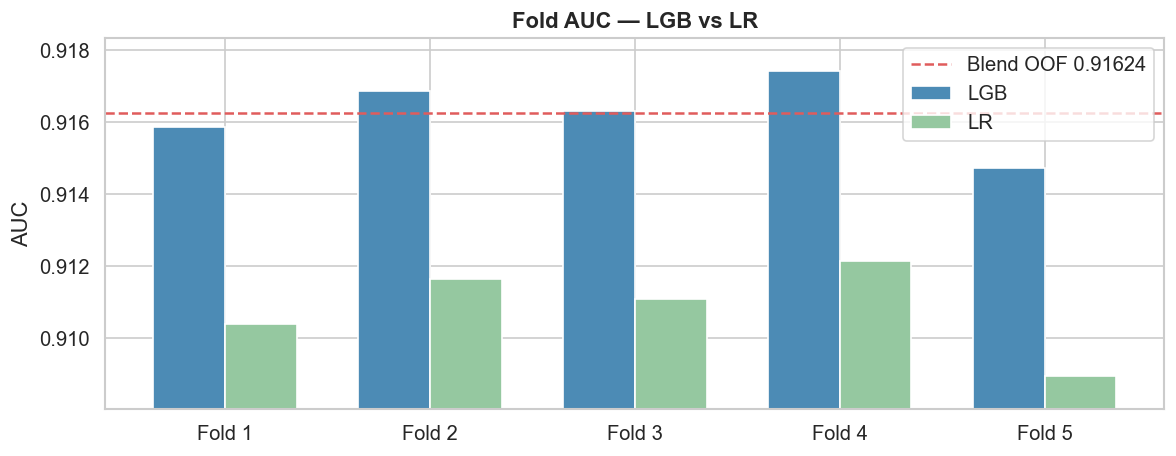

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC — all three
for label, oof, color in [
    ('LGB',   oof_lgb,   '#4C8BB5'),
    ('LR',    oof_lr,    '#95C8A0'),
    ('Blend', oof_blend, '#E05C5C'),
]:
    fpr, tpr, _ = roc_curve(y_train, oof)
    auc = roc_auc_score(y_train, oof)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{label} {auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1)
axes[0].set_title('ROC Curve — OOF', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Probability distributions — blend
axes[1].hist(oof_blend[y_train==0], bins=60, alpha=0.6,
             color='#4C8BB5', label='No Churn', density=True)
axes[1].hist(oof_blend[y_train==1], bins=60, alpha=0.6,
             color='#E05C5C', label='Churned', density=True)
axes[1].set_title('Blend — Predicted Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

# Calibration — blend
oof_df = pd.DataFrame({'prob': oof_blend, 'actual': y_train})
oof_df['decile'] = pd.qcut(oof_df['prob'], q=10, labels=False)
calib = oof_df.groupby('decile').agg(
    mean_pred=('prob','mean'), actual_rate=('actual','mean')
).reset_index()
axes[2].plot([0,1],[0,1],'k--',linewidth=1,label='Perfect')
axes[2].scatter(calib['mean_pred'], calib['actual_rate'], color='#E05C5C', s=80, zorder=5)
axes[2].plot(calib['mean_pred'], calib['actual_rate'], color='#E05C5C', linewidth=1.5, label='Blend')
axes[2].set_title('Calibration (deciles)', fontweight='bold')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Actual churn rate')
axes[2].legend()

plt.suptitle('OOF Analysis — Blend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Fold stability comparison
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_FOLDS)
w = 0.35
ax.bar(x - w/2, scores_lgb, width=w, label='LGB', color='#4C8BB5', edgecolor='white')
ax.bar(x + w/2, scores_lr,  width=w, label='LR',  color='#95C8A0', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, N_FOLDS+1)])
ax.axhline(best_auc, color='#E05C5C', linestyle='--', linewidth=1.5,
           label=f'Blend OOF {best_auc:.5f}')
ax.set_title('Fold AUC — LGB vs LR', fontweight='bold')
ax.set_ylabel('AUC')
ax.set_ylim(min(scores_lgb + scores_lr)*0.999, max(scores_lgb + scores_lr)*1.001)
ax.legend()
plt.tight_layout()
plt.show()


---
## 6. Feature Importance (LightGBM)

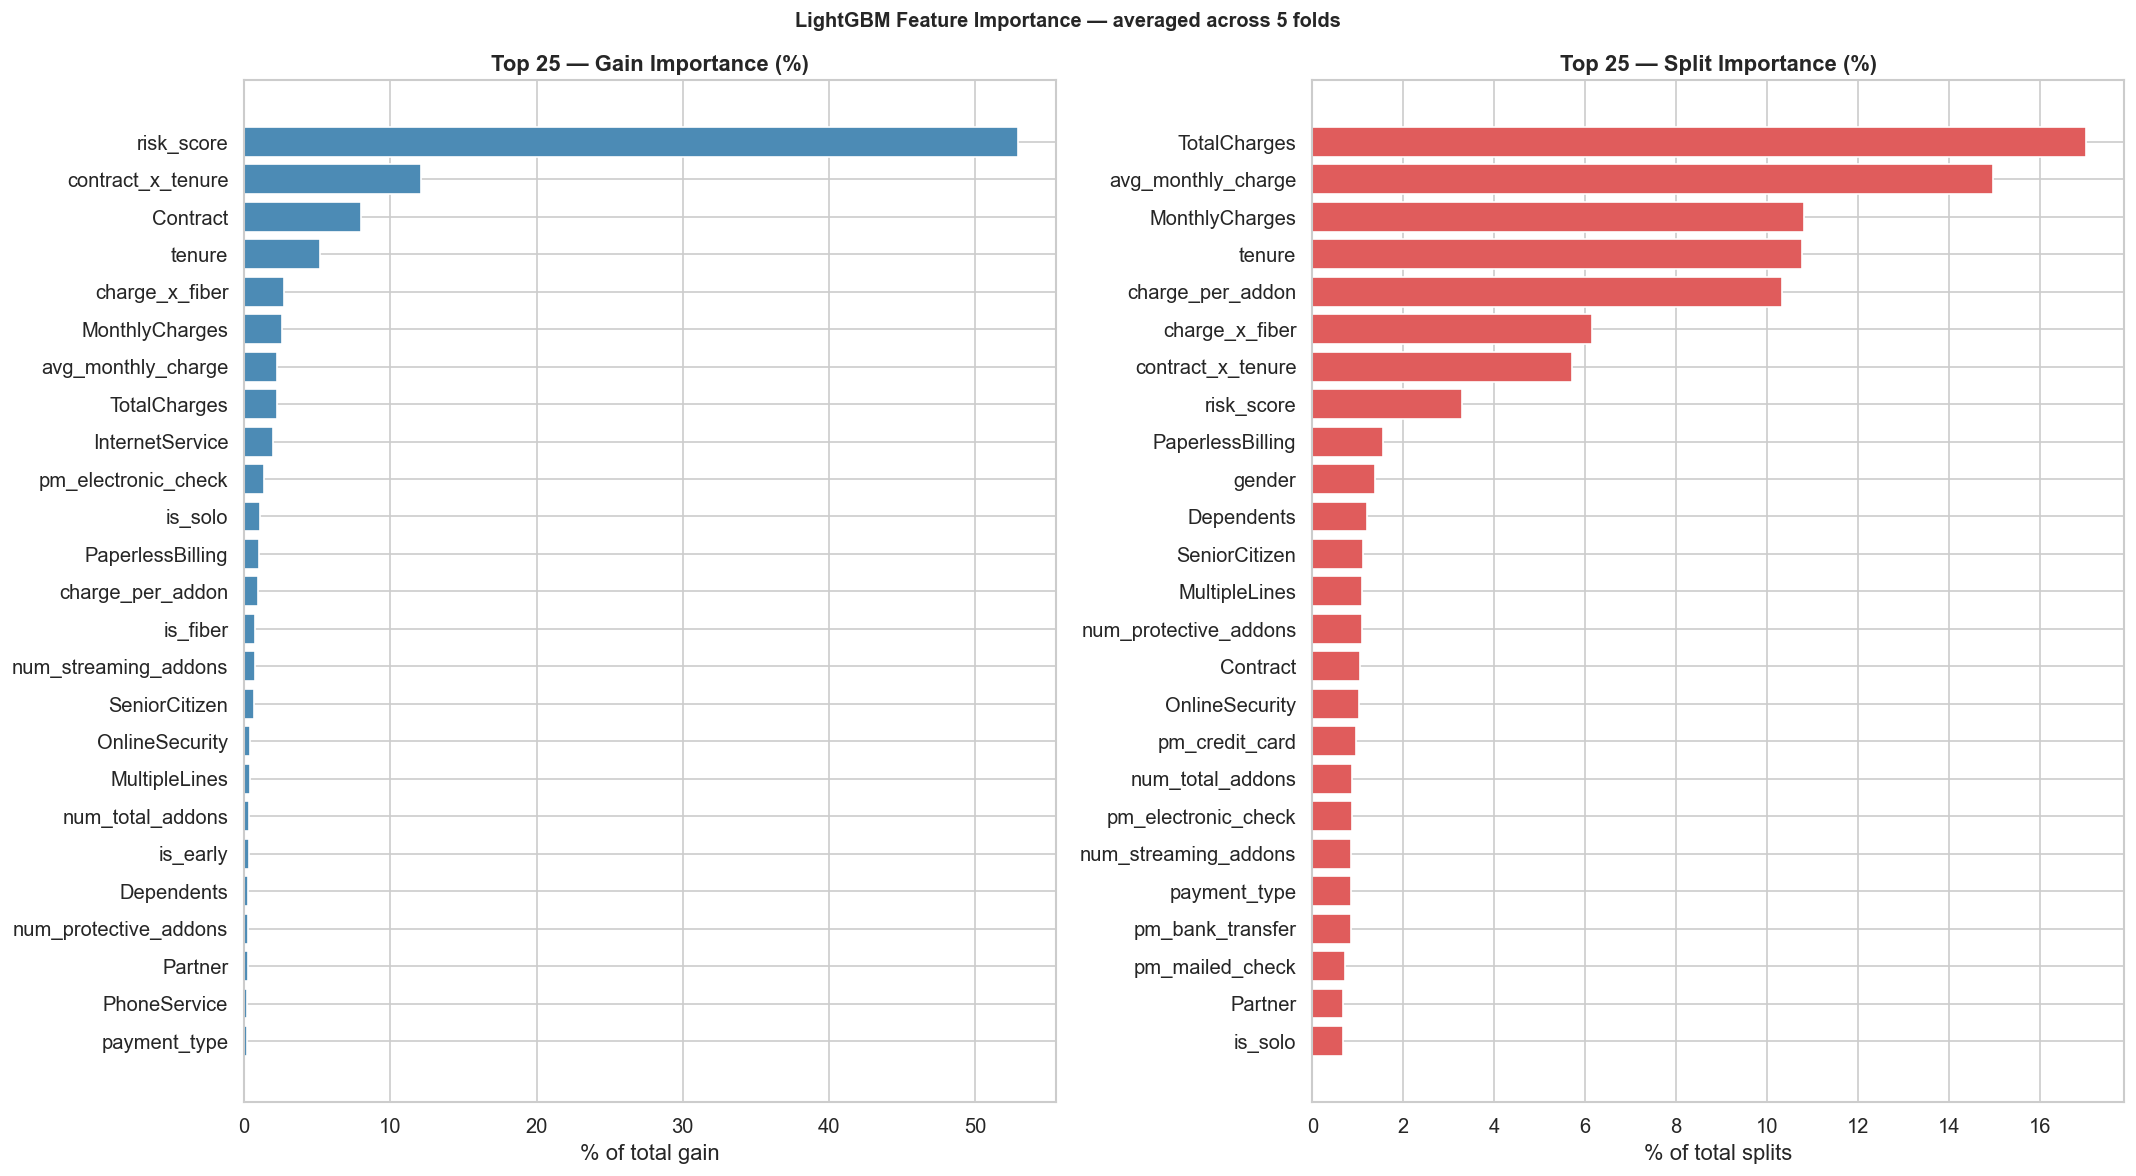

Top 20 by gain:
             feature  gain_norm  split_norm
          risk_score      52.92        3.30
   contract_x_tenure      12.12        5.71
            Contract       7.98        1.05
              tenure       5.18       10.77
      charge_x_fiber       2.69        6.16
      MonthlyCharges       2.58       10.82
  avg_monthly_charge       2.25       14.98
        TotalCharges       2.24       17.01
     InternetService       1.94        0.29
 pm_electronic_check       1.32        0.88
             is_solo       1.08        0.67
    PaperlessBilling       1.03        1.55
    charge_per_addon       0.97       10.33
            is_fiber       0.75        0.02
num_streaming_addons       0.75        0.86
       SeniorCitizen       0.68        1.11
      OnlineSecurity       0.40        1.03
       MultipleLines       0.37        1.09
    num_total_addons       0.34        0.88
            is_early       0.33        0.18

Features with <0.5% gain importance (25):
               fe

In [7]:
imp_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'gain_norm' : (gain_imp  / gain_imp.sum()  * 100).round(2),
    'split_norm': (split_imp / split_imp.sum() * 100).round(2),
}).sort_values('gain_norm', ascending=False).reset_index(drop=True)

top_n = 25
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].barh(imp_df['feature'][:top_n][::-1],
             imp_df['gain_norm'][:top_n][::-1],
             color='#4C8BB5', edgecolor='white')
axes[0].set_title(f'Top {top_n} — Gain Importance (%)', fontweight='bold')
axes[0].set_xlabel('% of total gain')

top_split = imp_df.sort_values('split_norm', ascending=False).head(top_n)
axes[1].barh(top_split['feature'][::-1], top_split['split_norm'][::-1],
             color='#E05C5C', edgecolor='white')
axes[1].set_title(f'Top {top_n} — Split Importance (%)', fontweight='bold')
axes[1].set_xlabel('% of total splits')

plt.suptitle('LightGBM Feature Importance — averaged across 5 folds',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 20 by gain:")
print(imp_df[['feature','gain_norm','split_norm']].head(20).to_string(index=False))
low = imp_df[imp_df['gain_norm'] < 0.5]
print(f"\nFeatures with <0.5% gain importance ({len(low)}):")
print(low[['feature','gain_norm']].to_string(index=False))


---
## 7. Submission

Sanity checks: ✅
Rows      : 254,655
Churn mean: 0.3408  (train: 0.2252)

Final OOF AUC (blend): 0.91624
  LGB  : 0.91622
  LR   : 0.91083
  Blend weights: LGB=0.95 / LR=0.05


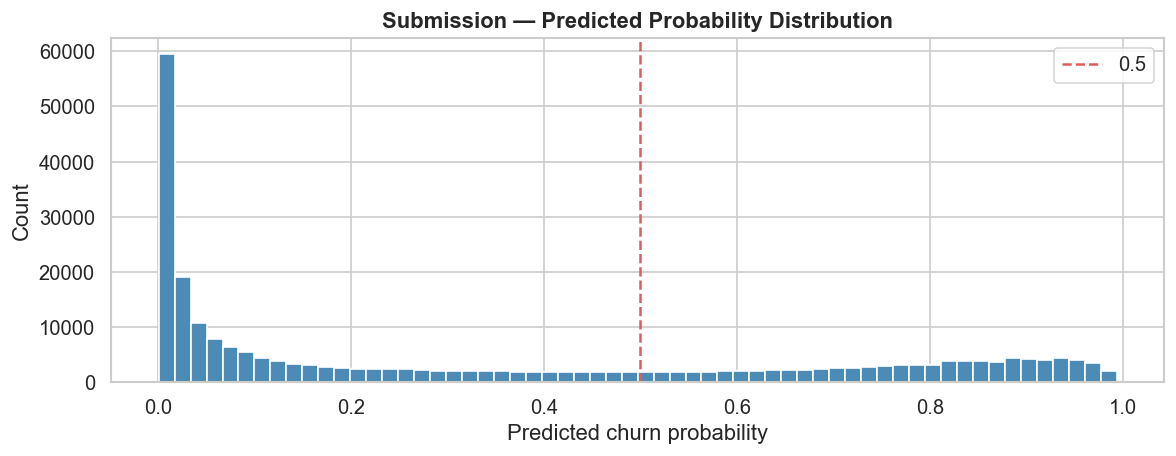


✅ Saved: /Users/clairedebadts/kaggle/customer-churn/submission.csv


In [8]:
import os

submission = pd.DataFrame({
    'id'   : test_ids['id'],
    'Churn': tst_blend
})

assert submission['id'].nunique() == len(submission)
assert submission['Churn'].between(0, 1).all()
assert submission.isnull().sum().sum() == 0
print("Sanity checks: ✅")
print(f"Rows      : {len(submission):,}")
print(f"Churn mean: {submission['Churn'].mean():.4f}  (train: {y_train.mean():.4f})")
print(f"\nFinal OOF AUC (blend): {best_auc:.5f}")
print(f"  LGB  : {auc_lgb:.5f}")
print(f"  LR   : {auc_lr:.5f}")
print(f"  Blend weights: LGB={best_w:.2f} / LR={1-best_w:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(submission['Churn'], bins=60, color='#4C8BB5', edgecolor='white')
ax.axvline(0.5, color='#E05C5C', linestyle='--', linewidth=1.5, label='0.5')
ax.set_title('Submission — Predicted Probability Distribution', fontweight='bold')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

os.makedirs(OUT_DIR, exist_ok=True)
submission.to_csv(OUT_DIR + "submission.csv", index=False)
print(f"\n✅ Saved: {OUT_DIR}submission.csv")
